In [ ]:
!git clone https://github.com/deepseek-ai/Janus.git

In [ ]:
%%capture
%cd Janus
!pip install -e .
!pip install flash-attn

# 模型准备

In [1]:
import torch
from transformers import AutoConfig, AutoModelForCausalLM
from janus.models import MultiModalityCausalLM, VLChatProcessor
from janus.utils.io import load_pil_images
from PIL import Image

import numpy as np
import os
import time

Python version is above 3.10, patching the collections module.


/usr/local/lib/python3.10/dist-packages/transformers/models/auto/image_processing_auto.py:524: FutureWarning: The image_processor_class argument is deprecated and will be removed in v4.42. Please use `slow_image_processor_class`, or `fast_image_processor_class` instead
  warnings.warn(


In [2]:
model_path = '/kaggle/input/janus-pro/pytorch/7b/1'

config = AutoConfig.from_pretrained(model_path)
language_config = config.language_config
language_config._attn_implementation = 'eager'

vl_gpt = AutoModelForCausalLM.from_pretrained(model_path,
                         language_config=language_config, 
                         device_map='auto', torch_dtype=torch.bfloat16,
                         trust_remote_code=True)

#cuda_device = 'cuda' if torch.cuda.is_available() else 'cpu'
cuda_device = vl_gpt.device

'''
if cuda_device == 'cuda':
    vl_gpt = vl_gpt.to(torch.bfloat16).cuda()
else:
    vl_gpt = vl_gpt.to(torch.float16)
'''

vl_chat_processor = VLChatProcessor.from_pretrained(model_path, device_map='auto')
tokenizer = vl_chat_processor.tokenizer

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

You are using the default legacy behaviour of the <class 'transformers.models.llama.tokenization_llama_fast.LlamaTokenizerFast'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565 - if you loaded a llama tokenizer from a GGUF file you can ignore this message.
Some kwargs in processor config are unused and will not have any effect: ignore_id, image_tag, add_special_token, sft_format, num_image_tokens, mask_prompt. 


# 模型预处理

# 理解模块

In [3]:
def multimodal_understanding(image, question, seed, top_p, temperature):
    # Clear CUDA cache before generating
    torch.cuda.empty_cache()
    
    # set seed
    torch.manual_seed(seed)
    np.random.seed(seed)
    torch.cuda.manual_seed(seed)
    
    conversation = [
        {
            "role": "<|User|>",
            "content": f"<image_placeholder>\n{question}",
            "images": [image],
        },
        {"role": "<|Assistant|>", "content": ""},
    ]
    
    pil_images = load_pil_images(conversation)
    prepare_inputs = vl_chat_processor(
        conversations=conversation, images=pil_images, force_batchify=True
    ).to(cuda_device, dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float16)
    
    
    inputs_embeds = vl_gpt.prepare_inputs_embeds(**prepare_inputs)
    
    outputs = vl_gpt.language_model.generate(
        inputs_embeds=inputs_embeds,
        attention_mask=prepare_inputs.attention_mask,
        pad_token_id=tokenizer.eos_token_id,
        bos_token_id=tokenizer.bos_token_id,
        eos_token_id=tokenizer.eos_token_id,
        max_new_tokens=512,
        do_sample=False if temperature == 0 else True,
        use_cache=True,
        temperature=temperature,
        top_p=top_p,
    )
    
    answer = tokenizer.decode(outputs[0].cpu().tolist(), skip_special_tokens=True)
    return answer

## 生成功能模块

In [4]:
def generate(input_ids,
             width,
             height,
             temperature: float = 1,
             parallel_size: int = 5,
             cfg_weight: float = 5,
             image_token_num_per_image: int = 576,
             patch_size: int = 16):
    # Clear CUDA cache before generating
    torch.cuda.empty_cache()
    
    tokens = torch.zeros((parallel_size * 2, len(input_ids)), dtype=torch.int).to(cuda_device)
    for i in range(parallel_size * 2):
        tokens[i, :] = input_ids
        if i % 2 != 0:
            tokens[i, 1:-1] = vl_chat_processor.pad_id
    inputs_embeds = vl_gpt.language_model.get_input_embeddings()(tokens)
    generated_tokens = torch.zeros((parallel_size, image_token_num_per_image), dtype=torch.int).to(cuda_device)

    pkv = None
    for i in range(image_token_num_per_image):
        with torch.no_grad():
            outputs = vl_gpt.language_model.model(inputs_embeds=inputs_embeds,
                                                use_cache=True,
                                                past_key_values=pkv)
            pkv = outputs.past_key_values
            hidden_states = outputs.last_hidden_state
            logits = vl_gpt.gen_head(hidden_states[:, -1, :])
            logit_cond = logits[0::2, :]
            logit_uncond = logits[1::2, :]
            logits = logit_uncond + cfg_weight * (logit_cond - logit_uncond)
            probs = torch.softmax(logits / temperature, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1)
            generated_tokens[:, i] = next_token.squeeze(dim=-1)
            next_token = torch.cat([next_token.unsqueeze(dim=1), next_token.unsqueeze(dim=1)], dim=1).view(-1)

            img_embeds = vl_gpt.prepare_gen_img_embeds(next_token)
            inputs_embeds = img_embeds.unsqueeze(dim=1)

    patches = vl_gpt.gen_vision_model.decode_code(generated_tokens.to(dtype=torch.int),
                                                 shape=[parallel_size, 8, width // patch_size, height // patch_size])

    return generated_tokens.to(dtype=torch.int), patches

def unpack(dec, width, height, parallel_size=5):
    dec = dec.to(torch.float32).cpu().numpy().transpose(0, 2, 3, 1)
    dec = np.clip((dec + 1) / 2 * 255, 0, 255)

    visual_img = np.zeros((parallel_size, width, height, 3), dtype=np.uint8)
    visual_img[:, :, :] = dec

    return visual_img

def generate_image(prompt,
                   seed=None,
                   guidance=5,
                   t2i_temperature=1.0):
    # Clear CUDA cache and avoid tracking gradients
    torch.cuda.empty_cache()
    # Set the seed for reproducible results
    if seed is not None:
        torch.manual_seed(seed)
        torch.cuda.manual_seed(seed)
        np.random.seed(seed)
    width = 384
    height = 384
    parallel_size = 5
    
    with torch.no_grad():
        messages = [{'role': '<|User|>', 'content': prompt},
                    {'role': '<|Assistant|>', 'content': ''}]
        text = vl_chat_processor.apply_sft_template_for_multi_turn_prompts(conversations=messages,
                                                                   sft_format=vl_chat_processor.sft_format,
                                                                   system_prompt='')
        text = text + vl_chat_processor.image_start_tag
        
        input_ids = torch.LongTensor(tokenizer.encode(text))
        output, patches = generate(input_ids,
                                   width // 16 * 16,
                                   height // 16 * 16,
                                   cfg_weight=guidance,
                                   parallel_size=parallel_size,
                                   temperature=t2i_temperature)
        images = unpack(patches,
                        width // 16 * 16,
                        height // 16 * 16,
                        parallel_size=parallel_size)

        return [Image.fromarray(images[i]).resize((768, 768), Image.LANCZOS) for i in range(parallel_size)]

# 模型推理

## 文搜图理解

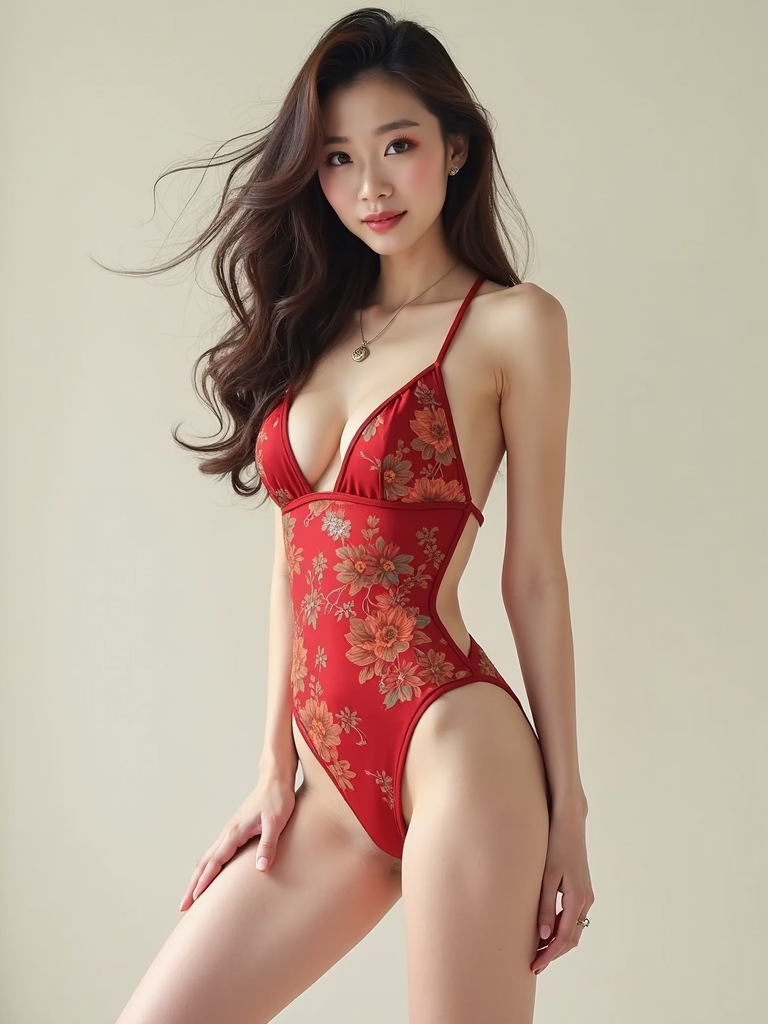

'图片中是一位穿着红色花卉图案连体泳衣的女性。她的头发是深棕色，披散着，看起来十分柔顺。她站立在一个浅色的背景前，姿势显得非常优雅。泳衣的布料看起来光滑，带有明显的花卉图案装饰，给人一种温暖而柔美的感觉。'

In [14]:
from IPython.display import display
from urllib.request import urlopen

#url = 'https://img.freepik.com/free-photo/modern-business-center_1127-3122.jpg'
#img = Image.open(urlopen(url))
#filename = 'example.jpg'
#img.save(filename)

img = Image.open("/kaggle/input/diffusion/HXRlOIUV2iP4FEgPKSVYH.png")
display(img)

answer = multimodal_understanding (
    image = "/kaggle/input/diffusion/HXRlOIUV2iP4FEgPKSVYH.png",
    question='图片有什么？',
    seed = 123,
    top_p = 0.8,
    temperature = 1.0
   )

answer 

In [10]:
from IPython.display import display
from urllib.request import urlopen


filename = '/kaggle/input/diffusion/zoE4w0sAoOAOuQeTuEk86.jpg'
#img.save(filename)

display(filename)

answer = multimodal_understanding (
    image = filename,
    question='识别图像中的物体或进行图像处理,进行目标检测',
    seed = 123,
    top_p = 0.8,
    temperature = 1.0
   )

answer 

'/kaggle/input/diffusion/zoE4w0sAoOAOuQeTuEk86.jpg'

'图像中没有明确的物体或物体进行检测的实例。图像似乎是一张展示人物穿着红色连体衣的照片。如果要进行图像处理或目标检测，可以提供更具体的物体或任务进行分析。'

## 文生图

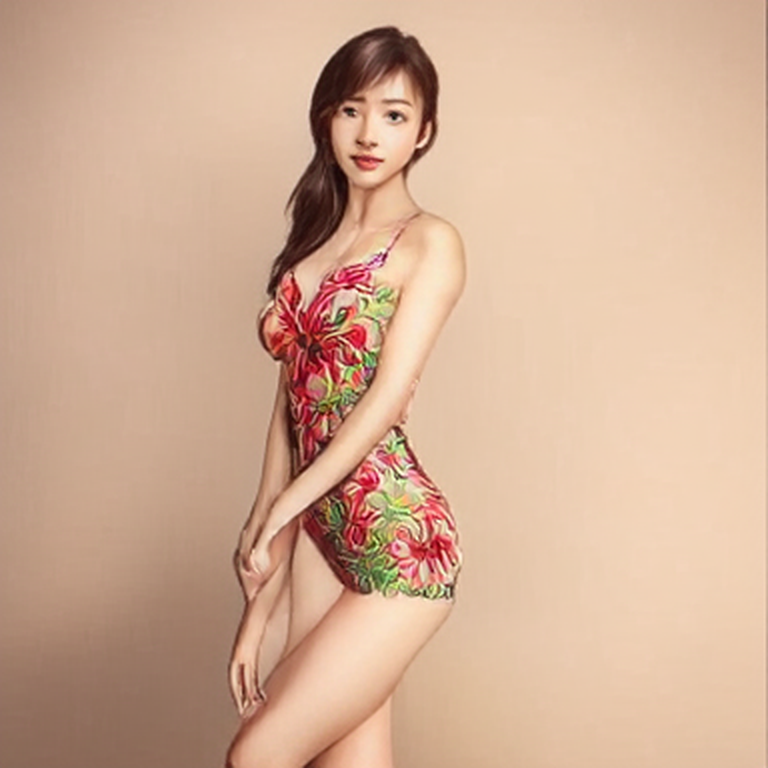

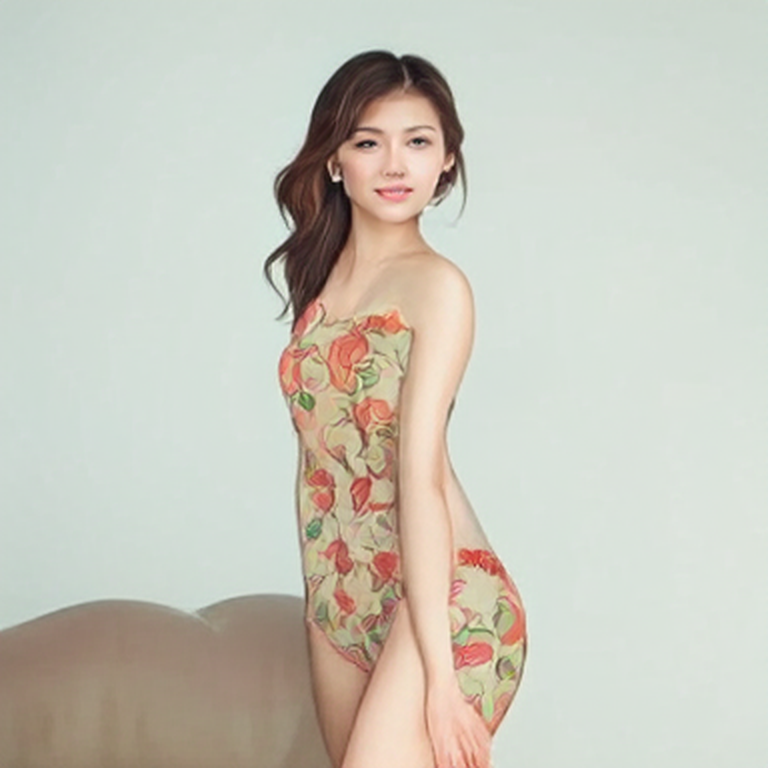

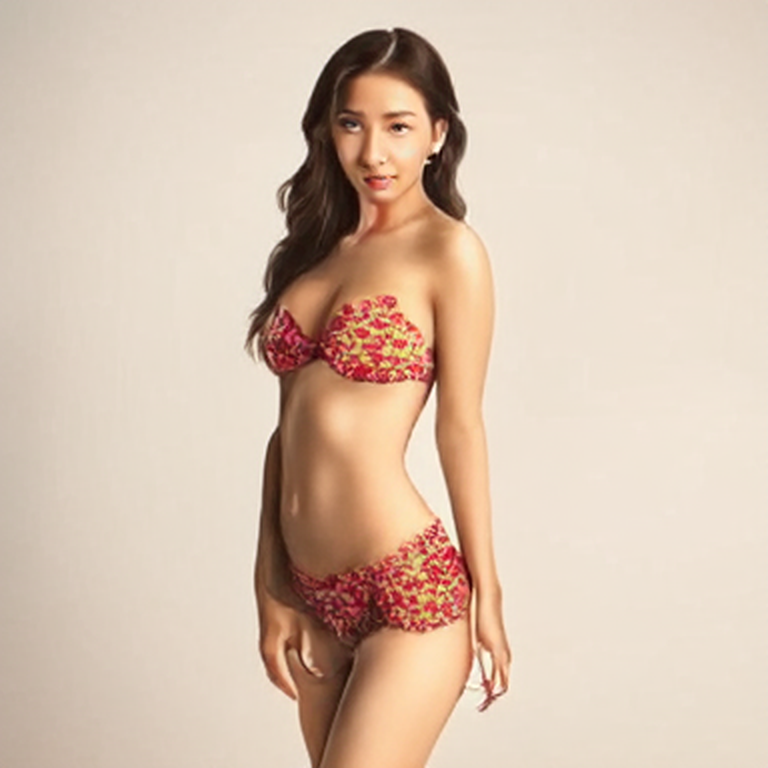

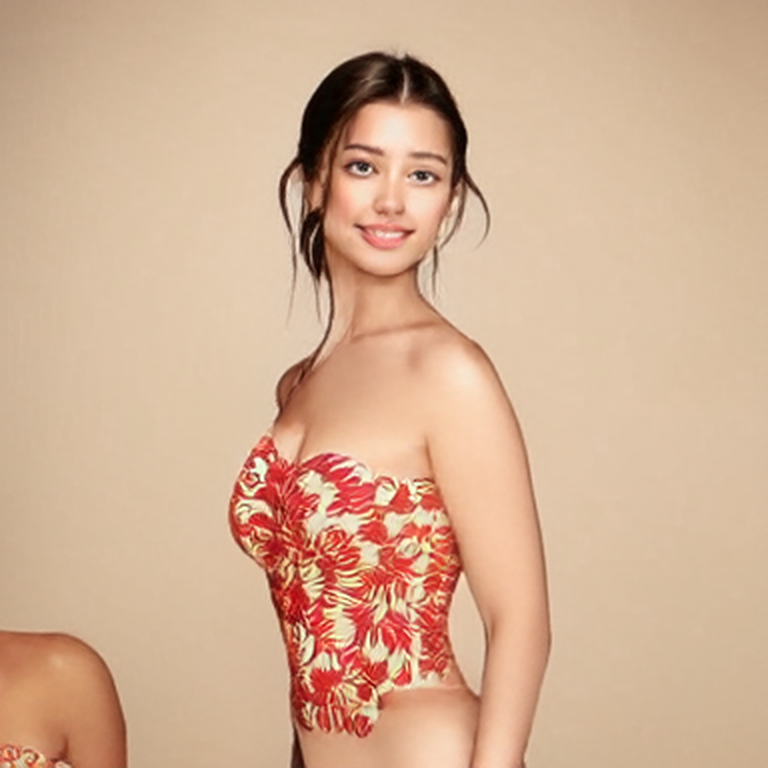

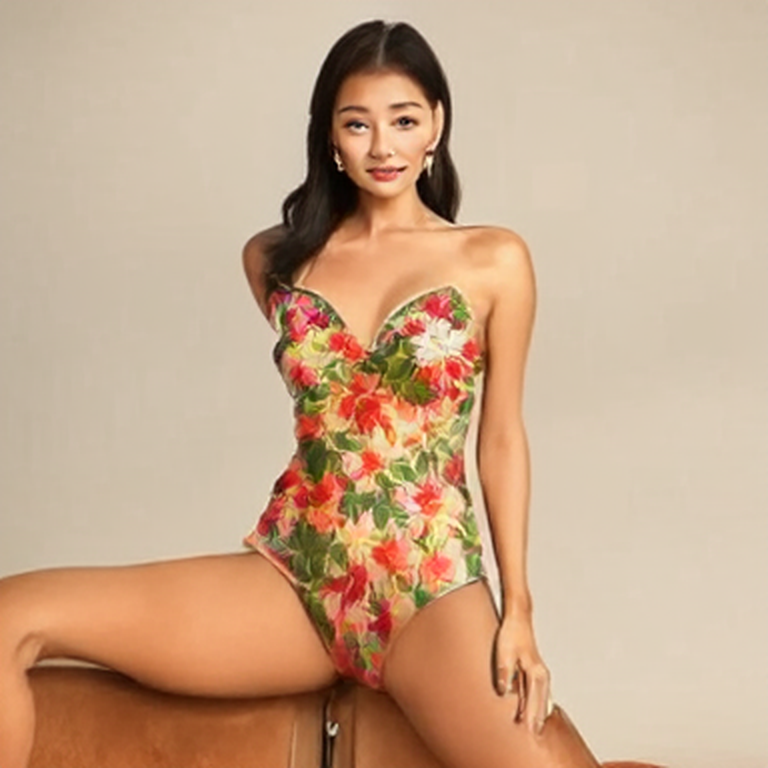

In [15]:
from IPython.display import display

#images = generate_image (answer)
images = generate_image (answer)
for i in range(len(images)):
    display(images[i])